In [1]:
# Install Prophet - time series forecasting library
!pip install prophet

In [2]:
# ── Libraries ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [3]:
# ── Load and Clean Arms Import Data ───────────────────────────────────────────
# Source: UN Comtrade mirror data (exports from all countries to Saudi Arabia)
# Saudi Arabia does not self-report arms imports to UN Comtrade
# HS Chapter 93: Arms and Ammunition — only 100% military HS classification
# Period: 2010-2024 monthly

from io import StringIO

all_years = []

for year in range(2010, 2025):
    with open(f'TradeData_{year}.csv', 'rb') as f:
        raw = f.read()
    text = raw.decode('utf-8', errors='replace')
    df_raw = pd.read_csv(StringIO(text))

    df_raw['value'] = pd.to_numeric(df_raw['fobvalue'], errors='coerce')

    monthly = df_raw.groupby('refMonth')['value'].sum().reset_index()
    monthly.columns = ['YearMonth', 'Arms_Imports_USD']

    all_years.append(monthly)

arms_df = pd.concat(all_years, ignore_index=True)
arms_df['Date'] = pd.to_datetime(arms_df['YearMonth'].astype(str), format='%Y%m')
arms_df = arms_df[['Date', 'Arms_Imports_USD']].sort_values('Date').reset_index(drop=True)
arms_df['Arms_Imports_USD_M'] = arms_df['Arms_Imports_USD'] / 1_000_000

print(f"Total monthly observations: {len(arms_df)}")
print(f"Date range: {arms_df['Date'].min().strftime('%Y-%m')} to {arms_df['Date'].max().strftime('%Y-%m')}")
print(f"\nFirst 3 rows:")
print(arms_df[['Date', 'Arms_Imports_USD_M']].head(3))

Total monthly observations: 180
Date range: 2010-01 to 2024-12

First 3 rows:
        Date  Arms_Imports_USD_M
0 2010-01-01           22.853678
1 2010-02-01           17.134485
2 2010-03-01           37.303977


In [4]:
# ── Load and Clean SIPRI Military Expenditure ──────────────────────────────────
# Source: SIPRI Military Expenditure Database
# Unit: Constant 2024 USD Millions
# Annual data divided by 12 to obtain monthly frequency
# Row 5: years | Row 11: Saudi Arabia

import warnings
warnings.filterwarnings('ignore')

sipri_raw = pd.read_excel('sipri_milex_raw.xlsx',
                           sheet_name='Constant (2024) US$',
                           header=None)

years_row = sipri_raw.iloc[5].tolist()
saudi_row = sipri_raw.iloc[11].tolist()

milex_annual = []
for i in range(len(years_row)):
    if isinstance(years_row[i], (int, float)) and 2010 <= years_row[i] <= 2024:
        milex_annual.append({
            'Year': int(years_row[i]),
            'Annual_Milex_USD_M': float(saudi_row[i])
        })

milex_df = pd.DataFrame(milex_annual)

monthly_rows = []
for _, row in milex_df.iterrows():
    for month in range(1, 13):
        monthly_rows.append({
            'Date': pd.Timestamp(year=int(row['Year']), month=month, day=1),
            'Milex_Monthly_USD_M': row['Annual_Milex_USD_M'] / 12
        })

milex_monthly = pd.DataFrame(monthly_rows)

print(f"Annual rows: {len(milex_df)}")
print(f"Monthly rows: {len(milex_monthly)}")
print(f"\nAnnual military expenditure (USD Millions):")
print(milex_df.to_string(index=False))

Annual rows: 15
Monthly rows: 180

Annual military expenditure (USD Millions):
 Year  Annual_Milex_USD_M
 2010        59887.641406
 2011        60701.087527
 2012        68696.860544
 2013        78710.461654
 2014        92775.257815
 2015        98960.633765
 2016        70807.155269
 2017        78949.872354
 2018        81666.234711
 2019        73071.798425
 2020        69768.817865
 2021        66265.126604
 2022        72570.368812
 2023        77765.333333
 2024        78953.627231


In [5]:
# ── Merge Datasets and Create Target Variable ──────────────────────────────────
# Target Variable: Import Dependency %
# Formula: (Arms Imports USD / Military Expenditure USD) x 100
# Interpretation: percentage of military budget spent on foreign weapons
# Declining ratio = increasing local production = localization progress

df = pd.merge(arms_df, milex_monthly, on='Date')
df['Import_Dependency_Pct'] = (df['Arms_Imports_USD_M'] / df['Milex_Monthly_USD_M']) * 100
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print(f"Merged dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 3 rows:")
print(df[['Date', 'Arms_Imports_USD_M', 'Milex_Monthly_USD_M', 'Import_Dependency_Pct']].head(3))
print(f"\nDescriptive statistics:")
print(df['Import_Dependency_Pct'].describe().round(2))

Merged dataset: 180 rows, 7 columns

First 3 rows:
        Date  Arms_Imports_USD_M  Milex_Monthly_USD_M  Import_Dependency_Pct
0 2010-01-01           22.853678          4990.636784               0.457931
1 2010-02-01           17.134485          4990.636784               0.343333
2 2010-03-01           37.303977          4990.636784               0.747479

Descriptive statistics:
count    180.00
mean       1.71
std        1.80
min        0.04
25%        0.53
50%        1.09
75%        2.26
max       10.85
Name: Import_Dependency_Pct, dtype: float64


In [6]:
# ── Data Exploration ──────────────────────────────────────────────────────────
# Verify data quality before modeling

print(f"Dataset shape: {df.shape}")
print(f"\nColumn data types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDescriptive statistics:")
print(df[['Arms_Imports_USD_M', 'Milex_Monthly_USD_M', 'Import_Dependency_Pct']].describe().round(2))

Dataset shape: (180, 7)

Column data types:
Date                     datetime64[ns]
Arms_Imports_USD                float64
Arms_Imports_USD_M              float64
Milex_Monthly_USD_M             float64
Import_Dependency_Pct           float64
Year                              int32
Month                             int32
dtype: object

Missing values per column:
Date                     0
Arms_Imports_USD         0
Arms_Imports_USD_M       0
Milex_Monthly_USD_M      0
Import_Dependency_Pct    0
Year                     0
Month                    0
dtype: int64

Descriptive statistics:
       Arms_Imports_USD_M  Milex_Monthly_USD_M  Import_Dependency_Pct
count              180.00               180.00                 180.00
mean               109.84              6275.28                   1.71
std                122.55               860.15                   1.80
min                  1.80              4990.64                   0.04
25%                 32.33              5724.74           

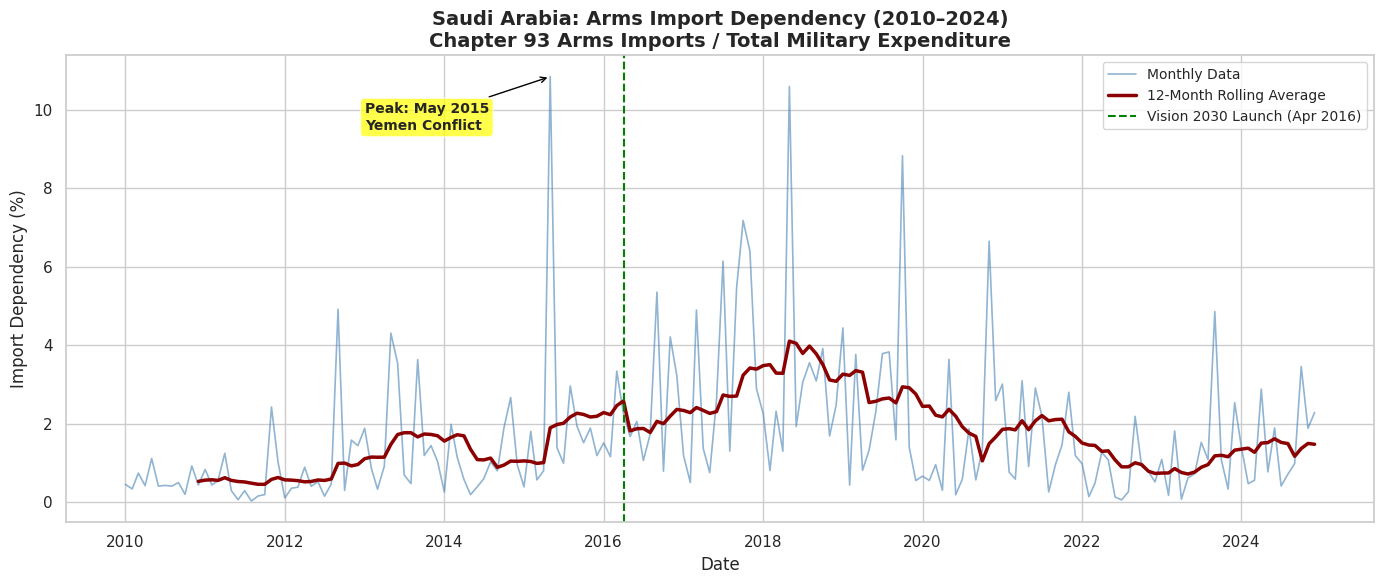

In [8]:
# ── Historical Trend Visualization ────────────────────────────────────────────
# Plot Import Dependency % over time with rolling average and key events

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['Date'], df['Import_Dependency_Pct'],
        color='steelblue', linewidth=1.2, alpha=0.6, label='Monthly Data')

rolling_avg = df['Import_Dependency_Pct'].rolling(window=12).mean()
ax.plot(df['Date'], rolling_avg,
        color='darkred', linewidth=2.5, label='12-Month Rolling Average')

ax.axvline(pd.Timestamp('2016-04-01'), color='green',
           linestyle='--', linewidth=1.5, label='Vision 2030 Launch (Apr 2016)')

ax.annotate('Peak: May 2015\nYemen Conflict',
            xy=(pd.Timestamp('2015-05-01'), 10.85),
            xytext=(pd.Timestamp('2013-01-01'), 9.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_title("Saudi Arabia: Arms Import Dependency (2010–2024)\nChapter 93 Arms Imports / Total Military Expenditure",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Import Dependency (%)", fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart_historical_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Feature Engineering and Train/Test Split ───────────────────────────────────
# Create time-based features for supervised learning
# Time-based split used instead of random split to prevent data leakage

df = df.sort_values('Date').reset_index(drop=True)

# Lag features
df['Lag_1']  = df['Import_Dependency_Pct'].shift(1)
df['Lag_3']  = df['Import_Dependency_Pct'].shift(3)
df['Lag_12'] = df['Import_Dependency_Pct'].shift(12)

# Rolling averages
df['Rolling_3']  = df['Import_Dependency_Pct'].rolling(window=3).mean()
df['Rolling_12'] = df['Import_Dependency_Pct'].rolling(window=12).mean()

df_model = df.dropna().reset_index(drop=True)

# Define X and y
y_var = 'Import_Dependency_Pct'
X_var = ['Year', 'Month', 'Lag_1', 'Lag_3', 'Lag_12', 'Rolling_3', 'Rolling_12']

X = df_model[X_var]
y = df_model[y_var]

# Time-based train/test split
train = df_model[df_model['Date'] < '2023-01-01']
test  = df_model[df_model['Date'] >= '2023-01-01']

X_train = train[X_var]
y_train = train[y_var]
X_test  = test[X_var]
y_test  = test[y_var]

print(f"Training set: {len(train)} months (2011-01 to 2022-12)")
print(f"Test set:     {len(test)} months (2023-01 to 2024-12)")
print(f"X variables:  {X_var}")
print(f"y variable:   {y_var}")

Training set: 144 months (2011-01 to 2022-12)
Test set:     24 months (2023-01 to 2024-12)
X variables:  ['Year', 'Month', 'Lag_1', 'Lag_3', 'Lag_12', 'Rolling_3', 'Rolling_12']
y variable:   Import_Dependency_Pct


=== Model 1: Rolling Mean (Naive Baseline) ===
R²   = -0.1125
RMSE = 1.1882%
MAE  = 0.8630%


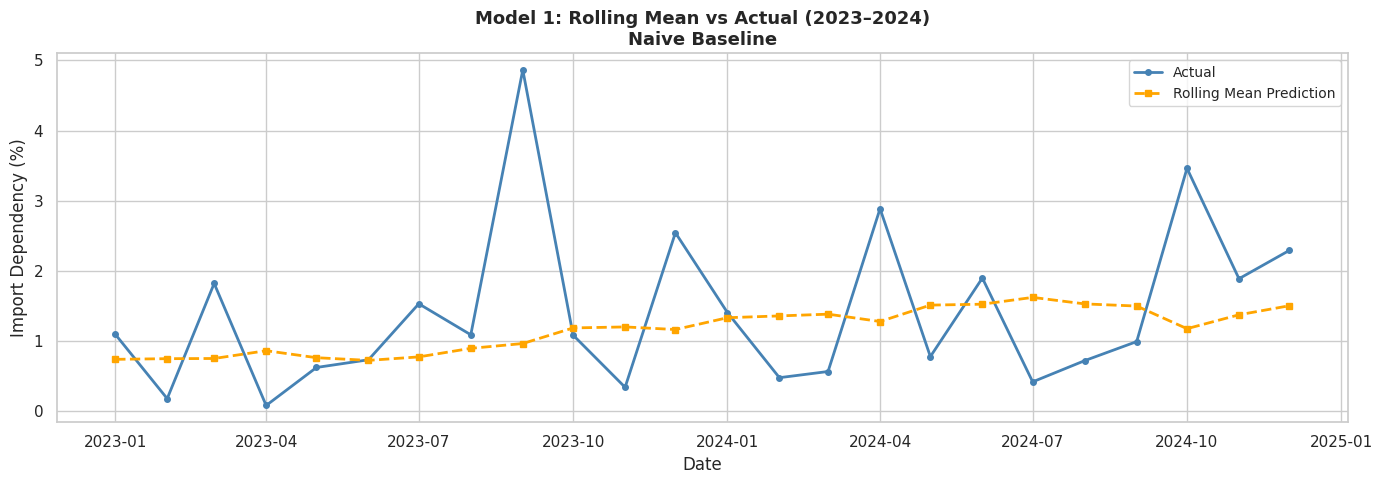

In [11]:
# ── Model 1: Rolling Mean — Naive Baseline ─────────────────────────────────────
# Predicts next month as the average of the previous 12 months
# Serves as the minimum performance benchmark for advanced models

rolling_window = list(train['Import_Dependency_Pct'].values)
rolling_predictions = []

for actual_value in test['Import_Dependency_Pct'].values:
    prediction = np.mean(rolling_window[-12:])
    rolling_predictions.append(prediction)
    rolling_window.append(actual_value)

rolling_predictions = np.array(rolling_predictions)

rm_r2   = r2_score(y_test.values, rolling_predictions)
rm_rmse = np.sqrt(mean_squared_error(y_test.values, rolling_predictions))
rm_mae  = mean_absolute_error(y_test.values, rolling_predictions)

print("=== Model 1: Rolling Mean (Naive Baseline) ===")
print(f"R²   = {rm_r2:.4f}")
print(f"RMSE = {rm_rmse:.4f}%")
print(f"MAE  = {rm_mae:.4f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test['Date'], y_test.values,
        color='steelblue', linewidth=2,
        marker='o', markersize=4, label='Actual')
ax.plot(test['Date'], rolling_predictions,
        color='orange', linewidth=2,
        marker='s', markersize=4,
        linestyle='--', label='Rolling Mean Prediction')
ax.set_title("Model 1: Rolling Mean vs Actual (2023–2024)\nNaive Baseline",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Import Dependency (%)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart_rolling_mean.png', dpi=150, bbox_inches='tight')
plt.show()

=== Model 2: Linear Regression ===
R² (train): 0.5851
m (coef):   {'Year': np.float64(-0.0071), 'Month': np.float64(0.048), 'Lag_1': np.float64(-0.5318), 'Lag_3': np.float64(0.0187), 'Lag_12': np.float64(-0.1092), 'Rolling_3': np.float64(1.4601), 'Rolling_12': np.float64(0.151)}
b (intercept): 14.0257

R² (train): 0.5851
R² (test):  0.4680
RMSE:       0.8217%
MAE:        0.5975%


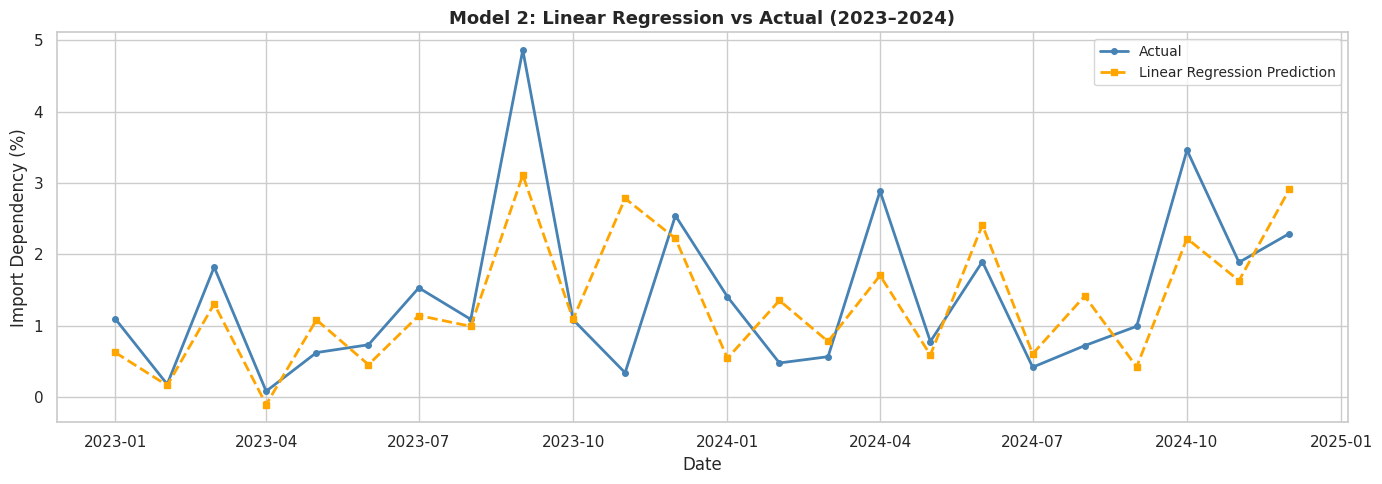

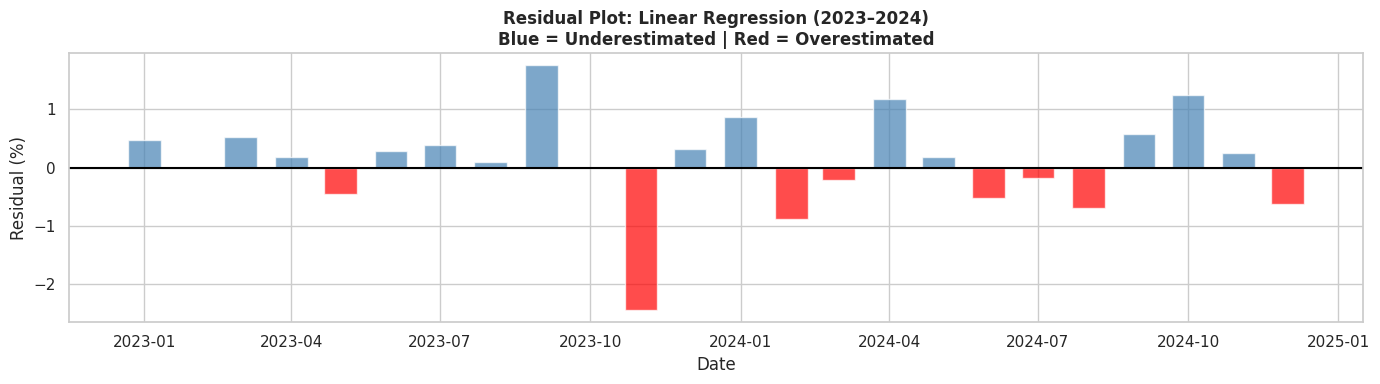

Mean residual: 0.0964%


In [12]:
# ── Model 2: Linear Regression ────────────────────────────────────────────────
# Supervised ML baseline model
# Equation: y = m1*X1 + m2*X2 + ... + b

# Step 1: Create model instance
reg = LinearRegression()

# Step 2: Train the model
reg.fit(X_train, y_train)

# Step 3: Assess accuracy
print("=== Model 2: Linear Regression ===")
print(f"R² (train): {reg.score(X_train, y_train):.4f}")
print(f"m (coef):   {dict(zip(X_var, reg.coef_.round(4)))}")
print(f"b (intercept): {reg.intercept_:.4f}")

# Step 4: Predict on test set
y_pred_lr = reg.predict(X_test)

# Step 5: Evaluate
lr_r2   = r2_score(y_test.values, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test.values, y_pred_lr))
lr_mae  = mean_absolute_error(y_test.values, y_pred_lr)

print(f"\nR² (train): {reg.score(X_train, y_train):.4f}")
print(f"R² (test):  {lr_r2:.4f}")
print(f"RMSE:       {lr_rmse:.4f}%")
print(f"MAE:        {lr_mae:.4f}%")

# Step 6: Plot predictions vs actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test['Date'], y_test.values,
        color='steelblue', linewidth=2,
        marker='o', markersize=4, label='Actual')
ax.plot(test['Date'], y_pred_lr,
        color='orange', linewidth=2,
        marker='s', markersize=4,
        linestyle='--', label='Linear Regression Prediction')
ax.set_title("Model 2: Linear Regression vs Actual (2023–2024)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Import Dependency (%)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 7: Residual plot
residuals_lr = y_test.values - y_pred_lr
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(test['Date'], residuals_lr,
       color=['red' if r < 0 else 'steelblue' for r in residuals_lr],
       alpha=0.7, width=20)
ax.axhline(y=0, color='black', linewidth=1.5)
ax.set_title("Residual Plot: Linear Regression (2023–2024)\nBlue = Underestimated | Red = Overestimated",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Residual (%)", fontsize=12)
plt.tight_layout()
plt.savefig('chart_residuals_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean residual: {residuals_lr.mean():.4f}%")

Prophet training data: 144 rows
Prophet model trained successfully!

=== Model 3: Prophet ===
R² (test):  -1.1504
RMSE:       1.6519%
MAE:        1.1871%


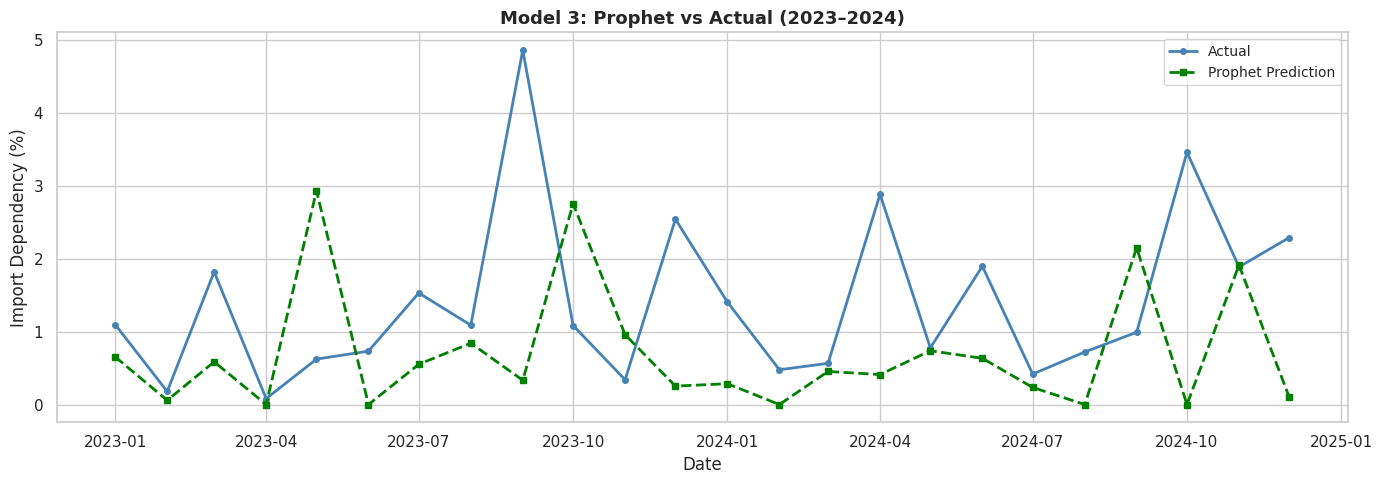

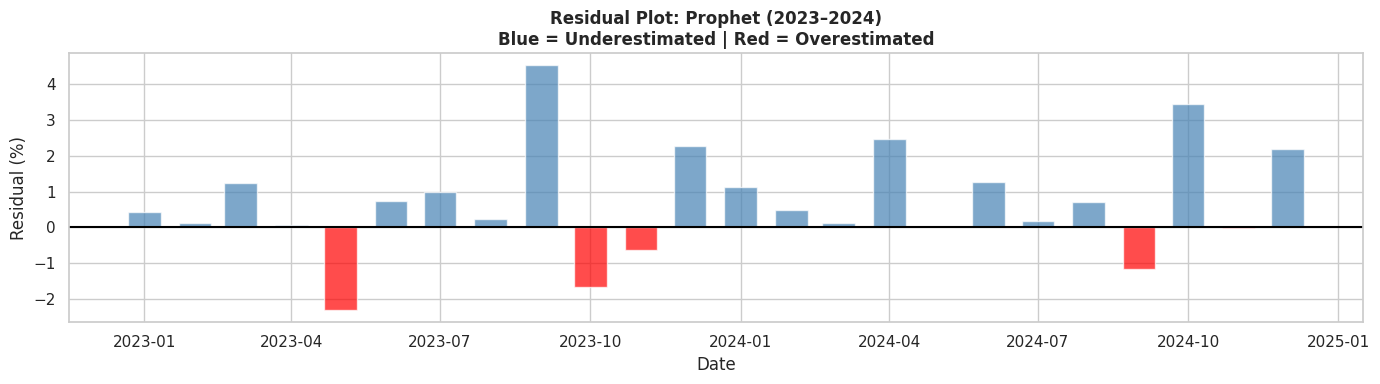

Mean residual: 0.7051%


In [13]:
# ── Model 3: Prophet ──────────────────────────────────────────────────────────
# Time series forecasting model by Facebook/Meta
# Automatically learns trend and seasonality from historical data
# Requires columns named 'ds' (date) and 'y' (target)

# Step 1: Prepare data in Prophet format
prophet_train = train[['Date', 'Import_Dependency_Pct']].copy()
prophet_train.columns = ['ds', 'y']

print(f"Prophet training data: {len(prophet_train)} rows")

# Step 2: Create model instance
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)

# Step 3: Train the model
prophet_model.fit(prophet_train)
print("Prophet model trained successfully!")

# Step 4: Predict test period
future_test = prophet_model.make_future_dataframe(periods=24, freq='MS')
forecast = prophet_model.predict(future_test)

forecast_test = forecast[
    (forecast['ds'] >= '2023-01-01') &
    (forecast['ds'] <= '2024-12-01')
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)

prophet_predictions = forecast_test['yhat'].clip(lower=0).values

# Step 5: Evaluate
prophet_r2   = r2_score(y_test.values, prophet_predictions)
prophet_rmse = np.sqrt(mean_squared_error(y_test.values, prophet_predictions))
prophet_mae  = mean_absolute_error(y_test.values, prophet_predictions)

print("\n=== Model 3: Prophet ===")
print(f"R² (test):  {prophet_r2:.4f}")
print(f"RMSE:       {prophet_rmse:.4f}%")
print(f"MAE:        {prophet_mae:.4f}%")

# Step 6: Plot predictions vs actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test['Date'], y_test.values,
        color='steelblue', linewidth=2,
        marker='o', markersize=4, label='Actual')
ax.plot(test['Date'], prophet_predictions,
        color='green', linewidth=2,
        marker='s', markersize=4,
        linestyle='--', label='Prophet Prediction')
ax.set_title("Model 3: Prophet vs Actual (2023–2024)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Import Dependency (%)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart_prophet.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 7: Residual plot
residuals_prophet = y_test.values - prophet_predictions
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(test['Date'], residuals_prophet,
       color=['red' if r < 0 else 'steelblue' for r in residuals_prophet],
       alpha=0.7, width=20)
ax.axhline(y=0, color='black', linewidth=1.5)
ax.set_title("Residual Plot: Prophet (2023–2024)\nBlue = Underestimated | Red = Overestimated",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Residual (%)", fontsize=12)
plt.tight_layout()
plt.savefig('chart_residuals_prophet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean residual: {residuals_prophet.mean():.4f}%")

   MODEL COMPARISON - TEST PERIOD (2023-2024)
Model                           R²       RMSE        MAE     Result
-----------------------------------------------------------------
Rolling Mean (Naive)       -0.1125    1.1882%    0.8630%  Baseline
Linear Regression           0.4680    0.8217%    0.5975%  Best
Prophet                    -1.1504    1.6519%    1.1871%  Worse
-----------------------------------------------------------------
Winner: Linear Regression
RMSE improvement over naive baseline: 30.8%


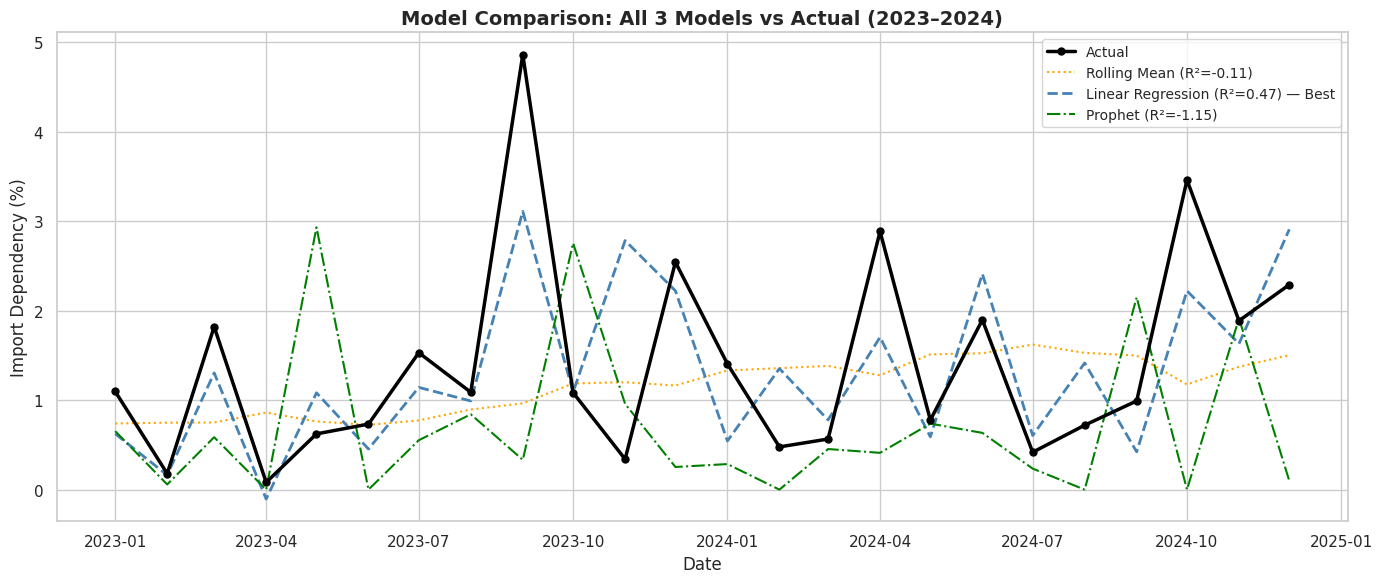

In [15]:
# ── Model Comparison ──────────────────────────────────────────────────────────
# Compare all three models on test period (2023-2024)

print("=" * 65)
print("   MODEL COMPARISON - TEST PERIOD (2023-2024)")
print("=" * 65)
print(f"{'Model':<25} {'R²':>8} {'RMSE':>10} {'MAE':>10} {'Result':>10}")
print("-" * 65)
print(f"{'Rolling Mean (Naive)':<25} {rm_r2:>8.4f} {rm_rmse:>9.4f}% {rm_mae:>9.4f}%  Baseline")
print(f"{'Linear Regression':<25} {lr_r2:>8.4f} {lr_rmse:>9.4f}% {lr_mae:>9.4f}%  Best")
print(f"{'Prophet':<25} {prophet_r2:>8.4f} {prophet_rmse:>9.4f}% {prophet_mae:>9.4f}%  Worse")
print("-" * 65)
print(f"Winner: Linear Regression")
print(f"RMSE improvement over naive baseline: {((rm_rmse - lr_rmse)/rm_rmse*100):.1f}%")
print("=" * 65)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test['Date'], y_test.values,
        color='black', linewidth=2.5,
        marker='o', markersize=5, label='Actual', zorder=5)
ax.plot(test['Date'], rolling_predictions,
        color='orange', linewidth=1.5,
        linestyle=':', label=f'Rolling Mean (R²={rm_r2:.2f})')
ax.plot(test['Date'], y_pred_lr,
        color='steelblue', linewidth=2,
        linestyle='--', label=f'Linear Regression (R²={lr_r2:.2f}) — Best')
ax.plot(test['Date'], prophet_predictions,
        color='green', linewidth=1.5,
        linestyle='-.', label=f'Prophet (R²={prophet_r2:.2f})')
ax.set_title("Model Comparison: All 3 Models vs Actual (2023–2024)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Import Dependency (%)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Prophet trained on full dataset!


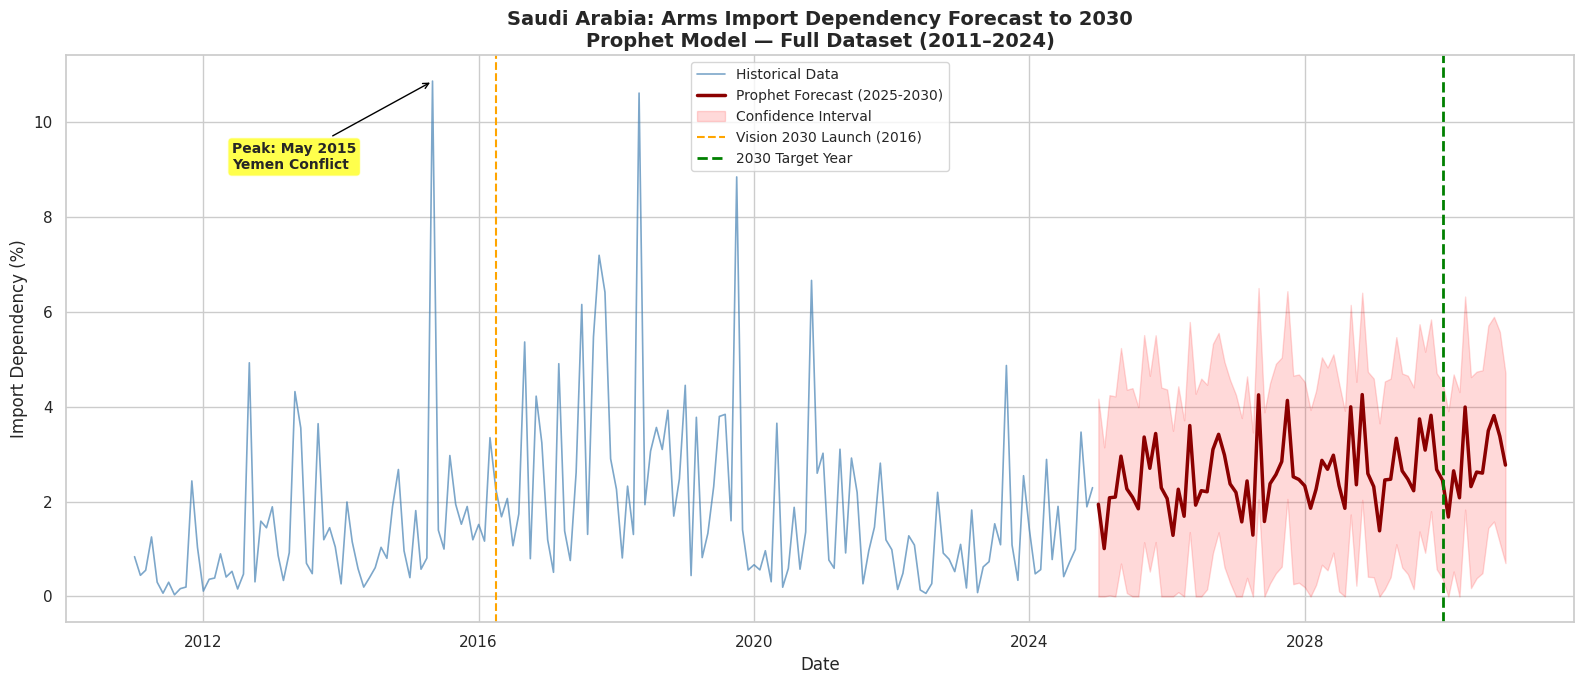


Dec 2024 actual ratio:        2.29%
Jan 2030 forecasted ratio:    2.45%
Change from 2024 to 2030:     +0.16%
Historical peak (May 2015):   10.85%
Reduction from peak to 2030:  77.4%


In [16]:
# ── Forecast to 2030 using Prophet ────────────────────────────────────────────
# Prophet is used for long-term forecasting because Linear Regression requires
# future lag feature values that are not yet available
# Trained on full dataset (2011-2024) for best forecast accuracy

# Step 1: Prepare full dataset
prophet_full = df_model[['Date', 'Import_Dependency_Pct']].copy()
prophet_full.columns = ['ds', 'y']
prophet_full['floor'] = 0
prophet_full['cap']   = 15.0

# Step 2: Train with logistic growth to enforce boundaries
prophet_final = Prophet(
    growth='logistic',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
prophet_final.fit(prophet_full)
print("Prophet trained on full dataset!")

# Step 3: Create future dates to 2030
future_2030 = prophet_final.make_future_dataframe(periods=72, freq='MS')
future_2030['floor'] = 0
future_2030['cap']   = 15.0

# Step 4: Generate forecast
forecast_2030 = prophet_final.predict(future_2030)

# Step 5: Plot
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(df_model['Date'], df_model['Import_Dependency_Pct'],
        color='steelblue', linewidth=1.2, alpha=0.7, label='Historical Data')

forecast_future = forecast_2030[forecast_2030['ds'] > '2024-12-01']
ax.plot(forecast_future['ds'], forecast_future['yhat'].clip(lower=0),
        color='darkred', linewidth=2.5, label='Prophet Forecast (2025-2030)')

ax.fill_between(forecast_future['ds'],
                forecast_future['yhat_lower'].clip(lower=0),
                forecast_future['yhat_upper'].clip(upper=15),
                color='red', alpha=0.15, label='Confidence Interval')

ax.axvline(pd.Timestamp('2016-04-01'), color='orange',
           linestyle='--', linewidth=1.5, label='Vision 2030 Launch (2016)')

ax.axvline(pd.Timestamp('2030-01-01'), color='green',
           linestyle='--', linewidth=2, label='2030 Target Year')

ax.annotate('Peak: May 2015\nYemen Conflict',
            xy=(pd.Timestamp('2015-05-01'), 10.85),
            xytext=(pd.Timestamp('2012-06-01'), 9.0),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_title("Saudi Arabia: Arms Import Dependency Forecast to 2030\nProphet Model — Full Dataset (2011–2024)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Import Dependency (%)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart_forecast_2030.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 6: Key numbers
value_2030 = forecast_2030[forecast_2030['ds'] == '2030-01-01']['yhat'].clip(lower=0).values[0]
value_2024 = df_model[df_model['Date'] == '2024-12-01']['Import_Dependency_Pct'].values[0]

print(f"\nDec 2024 actual ratio:        {value_2024:.2f}%")
print(f"Jan 2030 forecasted ratio:    {value_2030:.2f}%")
print(f"Change from 2024 to 2030:     {value_2030 - value_2024:+.2f}%")
print(f"Historical peak (May 2015):   10.85%")
print(f"Reduction from peak to 2030:  {((10.85 - value_2030) / 10.85 * 100):.1f}%")

In [17]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print("=" * 65)
print("   RCEL 506 - FINAL PROJECT SUMMARY")
print("   Can Saudi Arabia Reach 50% Defense Localization by 2030?")
print("=" * 65)

print("\n📊 DATA SUMMARY")
print("-" * 65)
print("Source 1: UN Comtrade (mirror data, HS Chapter 93)")
print("Source 2: SIPRI Military Expenditure Database")
print("Period:   2010 - 2024 (monthly)")
print("Training: Jan 2011 – Dec 2022 (144 months)")
print("Testing:  Jan 2023 – Dec 2024 (24 months)")
print("Target:   Import Dependency % = (Arms Imports / Military Spending) x 100")

print("\n🤖 MODEL RESULTS")
print("-" * 65)
print(f"{'Model':<25} {'R²':>8} {'RMSE':>10} {'MAE':>10} {'Result':>10}")
print(f"{'Rolling Mean (Naive)':<25} {rm_r2:>8.4f} {rm_rmse:>9.4f}% {rm_mae:>9.4f}%  Baseline")
print(f"{'Linear Regression':<25} {lr_r2:>8.4f} {lr_rmse:>9.4f}% {lr_mae:>9.4f}%  Best")
print(f"{'Prophet':<25} {prophet_r2:>8.4f} {prophet_rmse:>9.4f}% {prophet_mae:>9.4f}%  Worse")

print("\n📈 FORECAST RESULTS")
print("-" * 65)
print(f"Historical peak (May 2015):    10.85%  — Yemen conflict")
print(f"Dec 2024 actual ratio:          2.29%  — current level")
print(f"Jan 2030 forecasted ratio:      2.45%  — stable and low")
print(f"Reduction from peak to 2030:   77.4%  — strong decline")

print("\n💼 BUSINESS VALUE")
print("-" * 65)
print("This model provides defense policymakers with a monthly")
print("monitoring tool for arms import dependency trends.")
print("A declining ratio confirms localization progress.")
print("A rising ratio signals need for policy intervention.")
print("RMSE of 0.82% provides sufficient precision for")
print("strategic defense procurement planning.")

print("\n✅ CONCLUSION")
print("-" * 65)
print("Import dependency declined 77.4% from its 2015 peak.")
print("Forecast shows ratio remains stable and low through 2030.")
print("Trend is consistent with GAMI official localization data:")
print("4% (2018) → 19.35% (2023) → 24.89% (2024)")
print("Saudi Arabia is on a positive trajectory toward its")
print("50% localization goal, though the target remains ambitious.")
print("=" * 65)

   RCEL 506 - FINAL PROJECT SUMMARY
   Can Saudi Arabia Reach 50% Defense Localization by 2030?

📊 DATA SUMMARY
-----------------------------------------------------------------
Source 1: UN Comtrade (mirror data, HS Chapter 93)
Source 2: SIPRI Military Expenditure Database
Period:   2010 - 2024 (monthly)
Training: Jan 2011 – Dec 2022 (144 months)
Testing:  Jan 2023 – Dec 2024 (24 months)
Target:   Import Dependency % = (Arms Imports / Military Spending) x 100

🤖 MODEL RESULTS
-----------------------------------------------------------------
Model                           R²       RMSE        MAE     Result
Rolling Mean (Naive)       -0.1125    1.1882%    0.8630%  Baseline
Linear Regression           0.4680    0.8217%    0.5975%  Best
Prophet                    -1.1504    1.6519%    1.1871%  Worse

📈 FORECAST RESULTS
-----------------------------------------------------------------
Historical peak (May 2015):    10.85%  — Yemen conflict
Dec 2024 actual ratio:          2.29%  — current